In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [3]:
x = np.arange(0, 12).reshape(3, 4)
y = np.array([True, False, True])
print(y)
print(x)
x[y, 1]



[ True False  True]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


array([1, 9])

In [2]:
#x是特征，y是标签
x, y = datasets.make_moons(n_samples=50000, noise=0.3, random_state=42)
print(x.shape)
print(y.shape)
print(np.unique(y))

(50000, 2)
(50000,)
[0 1]


In [14]:
x, y = datasets.make_moons(n_samples=50000, noise=0.3, random_state=666)
x[:10]
# 画图

array([[ 2.17839532, -0.51982396],
       [ 0.18452377,  0.0575255 ],
       [-0.77994482,  0.49013401],
       [ 2.13678701,  0.19170479],
       [ 1.83608146, -0.84228922],
       [ 0.59313334, -0.78954636],
       [ 0.46501814,  1.1305074 ],
       [-0.80919375,  0.00602556],
       [ 1.2234385 , -0.58108948],
       [ 0.16443543,  0.90001387]])

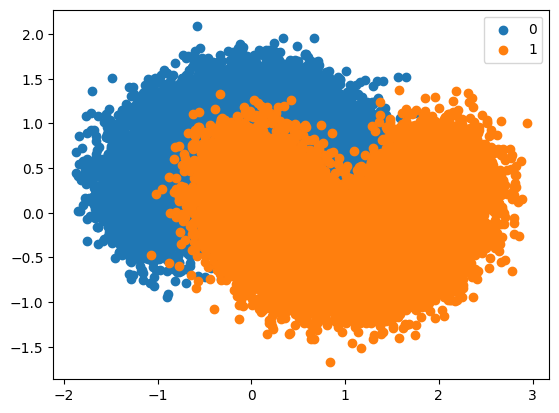

In [3]:

plt.scatter(x[y == 0, 0], x[y == 0, 1])  #拿到特征中标签为0的第0列，拿到标签为0的第一列
plt.scatter(x[y == 1, 0], x[y == 1, 1])  #拿到特征中标签为1的第0列，拿到标签为1的第一列
plt.legend(['0', '1'])
plt.show()  #图形的点颜色是自动的

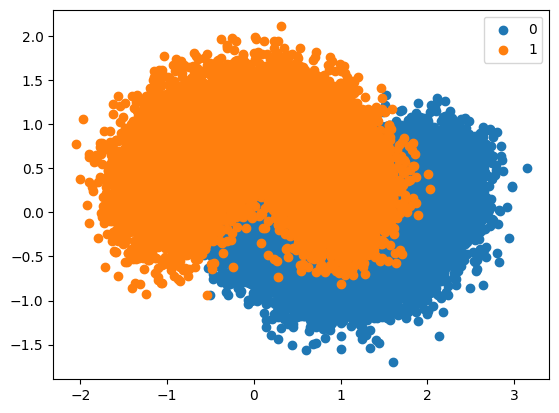

In [15]:
plt.scatter(x[y == 1, 0], x[y == 1, 1])
plt.scatter(x[y == 0, 0], x[y == 0, 1])
plt.legend(['0', '1'])
plt.show()  #图形的点颜色是自动的

In [ ]:
# x[y == 0, 0]

In [5]:
x[0:10]

array([[ 0.71820567, -0.21809028],
       [ 0.11096372,  1.10964541],
       [ 0.61562814, -0.06539887],
       [ 0.46175947,  1.17926518],
       [ 1.22553968, -0.51211163],
       [ 1.27989488,  0.19395679],
       [ 0.51249388,  1.21727796],
       [ 1.97017831,  0.3277893 ],
       [ 0.63961463,  0.9269041 ],
       [ 0.38809941, -0.32770396]])

In [7]:
np.unique(y)

array([0, 1], dtype=int64)

In [16]:
#默认分割比例是75%和25%
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression

#逻辑回归是搞分类的
log_clf = LogisticRegression()
log_clf.fit(x_train, y_train)
log_clf.score(x_test, y_test)

0.85184

In [19]:
# 2.支持向量机
from sklearn.svm import SVC


svm_clf = SVC()  #支持向量机
svm_clf.fit(x_train, y_train)
svm_clf.score(x_test, y_test)

0.9144

In [20]:
from sklearn.tree import DecisionTreeClassifier
# 决策树分类器
dt_clf = DecisionTreeClassifier()
dt_clf.fit(x_train, y_train)
dt_clf.score(x_test, y_test)

0.87432

# 1 手动实现投票分类器

In [8]:
#训练好模型，测试集做预测
# 手动模拟并行集成学习
y_predict1 = log_clf.predict(x_test)
y_predict2 = svm_clf.predict(x_test)
y_predict3 = dt_clf.predict(x_test)

In [9]:
#bagging，纯手动bagging
y_predict = np.array((y_predict1 + y_predict2 + y_predict3) >= 2, dtype='int')
y_predict[:10]

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 1])

In [10]:
y_test[:10]

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 1], dtype=int64)

In [11]:
from sklearn.metrics import accuracy_score

#accuracy_score计算准确率的
accuracy_score(y_test, y_predict)

0.90448

# 2 集成学习VotingClassifier(并行)

In [12]:
from sklearn.ensemble import VotingClassifier

#hard模式就是少数服从多数
voting_clf = VotingClassifier(estimators=[
    ('log_clf', LogisticRegression()),
    ('svm_clf', SVC()),
    ('dt_clf', DecisionTreeClassifier())], voting='hard')

In [14]:
voting_clf.fit(x_train, y_train)
print(voting_clf.score(x_test, y_test))
voting_clf.predict(x_test)[:10]

0.90408


array([1, 1, 1, 0, 0, 0, 0, 0, 0, 1], dtype=int64)

更合理的投票，应该有权值
唱歌比赛的投票?(评委的投票权重与观众不一样)
硬投票和软投票的区别：
硬投票：少数服从多数
软投票：每个分类器都给出一个概率，然后根据概率加权，预测为正的概率最高的分类器。

In [15]:
# hard和soft区别请看课件解释,训练时间久
voting_clf2 = VotingClassifier(estimators=[
    ('log_clf', LogisticRegression()),
    ('svm_clf', SVC(probability=True)),  #支持向量机中需要加入probability
    ('dt_clf', DecisionTreeClassifier())], voting='soft')
voting_clf2.fit(x_train, y_train)
voting_clf2.score(x_test, y_test)


0.90432

# 使用bagging,并行

In [16]:
50000 * 0.75

37500.0

In [22]:
from sklearn.tree import DecisionTreeClassifier  #用决策树集成上千模型
from sklearn.ensemble import BaggingClassifier
# from sklearn.ensemble import BaggingClassifier
#估计器数目是5000呢？bootstrap是有放回抽样,max_samples不可以超过训练集的数目37500
bagging_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300,
                                max_samples=3000, bootstrap=True)
bagging_clf.fit(x_train, y_train)
bagging_clf.score(x_test, y_test)

0.91464

# 3 oob设计

In [24]:
from sklearn.tree import DecisionTreeClassifier  #用决策树集成上千模型
from sklearn.ensemble import BaggingClassifier

#当去做有放回的抽样时，把没有取到的样本作为验证集，可以用oob_score来评估
bagging_clf2 = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300, max_samples=3000,
                                 bootstrap=True,
                                 oob_score=True)
bagging_clf2.fit(x_train, y_train)
print(bagging_clf2.score(x_test, y_test))
bagging_clf2.oob_score_  #拿没有取到的样本作为验证集

0.91488


0.9124

In [17]:
bagging_clf2.score(x_test, y_test)

0.91216

### njobs

In [19]:
from sklearn.tree import DecisionTreeClassifier  #用决策树集成上千模型
from sklearn.ensemble import BaggingClassifier

In [20]:
%%time
bagging_clf = BaggingClassifier(DecisionTreeClassifier(),
                                n_estimators=500, max_samples=2000,
                                bootstrap=True)
bagging_clf.fit(x_train, y_train)
bagging_clf.score(x_test, y_test)
#cpu time是实际cpu运行算法时间，wall time是墙上真实时间，就是real time（包含了进程启动时间，I/O等待时间等）

CPU times: total: 1.02 s
Wall time: 2.37 s


0.91208

In [21]:
%%time
#多核使用的时间更小, %%time要顶格来写
bagging_clf = BaggingClassifier(DecisionTreeClassifier(),
                                n_estimators=500, max_samples=2000,
                                bootstrap=True, n_jobs=-1)
bagging_clf.fit(x_train, y_train)
bagging_clf.score(x_test, y_test)

CPU times: total: 46.9 ms
Wall time: 3.05 s


0.91248

# 4 bootstrap_features  对特征进行采样

In [22]:
#因为我们就两个特征，所以max_features设置为1,得到的分值较低是因为我们特征较少，采用随机特征不合适
#这个是只对特征进行采样
random_subspaces_clf = BaggingClassifier(DecisionTreeClassifier(),
                                         n_estimators=500, max_samples=500, oob_score=True,
                                         bootstrap=True, n_jobs=-1,
                                         max_features=1, bootstrap_features=True)
random_subspaces_clf.fit(x, y)
random_subspaces_clf.oob_score_

0.88226

In [23]:
# 这里是为了验证总的抽样的样本数不能大于训练集的数目
random_patches_clf = BaggingClassifier(DecisionTreeClassifier(),
                                       n_estimators=500, max_samples=50001, oob_score=True,
                                       bootstrap=True, n_jobs=-1,
                                       max_features=1, bootstrap_features=True)
random_patches_clf.fit(x, y)
random_patches_clf.oob_score_
#这个代码有另外一个名字就是随机森林

ValueError: max_samples must be <= n_samples

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
%%time

rc_clf = RandomForestClassifier(n_estimators=500, random_state=666,
                                oob_score=True, n_jobs=-1)
rc_clf.fit(x, y)
rc_clf.oob_score_

CPU times: total: 26.5 s
Wall time: 2.85 s


0.90268

In [41]:
%%time
rc_clf = RandomForestClassifier(max_samples=37500, n_jobs=-1)
rc_clf.fit(x_train, y_train)
rc_clf.score(x_test, y_test)

CPU times: total: 8.03 s
Wall time: 1.53 s


0.90296

In [29]:
%%time
#max_leaf_nodes 最大的叶子结点数
rc_clf2 = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 random_state=666,
                                 oob_score=True, n_jobs=-1)
rc_clf2.fit(x, y)
rc_clf2.oob_score_

CPU times: total: 36.8 s
Wall time: 7.55 s


0.90962

## 小总结：并行集成学习的超参：
- n_estimators: 基分类器的数目
- max_samples: 基分类器训练集的大小
- max_features: 基分类器训练集的特征数目
- bootstrap: 是否采用有放回的抽样
- n_jobs: -1表示多核运行，其他数字表示具体核数
- oob_score: 是否用随机抽样没有选中的数据作为验证集
- max_leaf_nodes: 决策树的最大叶子结点数

# 5 Extra-Trees
ExtraTreesClassifier 是一种机器学习算法，属于基于决策树的集成方法家族。
它随机选择特征子集和数据样本来构建多个决策树，并将它们的预测聚合起来做出最终预测。
它可用于分类任务，并以处理嘈杂和高维数据的能力而闻名。

In [27]:
from sklearn.ensemble import ExtraTreesClassifier

et_clf = ExtraTreesClassifier(n_estimators=500, oob_score=True,
                              bootstrap=True, n_jobs=-1)
et_clf.fit(x, y)
et_clf.oob_score_

0.90654

# Boosting

# 5 串行（包含adaboost和GBDT）

In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [31]:
%%time
ada_clf = AdaBoostClassifier(DecisionTreeClassifier(),
                             n_estimators=500)
ada_clf.fit(x_train, y_train)
ada_clf.score(x_test, y_test)


CPU times: total: 62.5 ms
Wall time: 94.4 ms


0.87632

In [32]:
#它默认用的也是决策树，增加了基分类器的数目后，准确率提升
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(max_depth=3, n_estimators=500)
gb_clf.fit(x_train, y_train)
gb_clf.score(x_test, y_test)

0.91232

In [3]:
import numpy as np

print(np.log(9))  #当错误率是0.1时权重是2.19
np.log((1 - 0.5) / 0.5)  #当错误率是0.5时，权重是0

2.1972245773362196


0.0

In [35]:
!ls

01.py
02.py
03.py
03_鏁版嵁淇濆瓨.py
04.py
1-鐗瑰緛宸ョ▼.ipynb
1-鐗瑰緛宸ョ▼_鍐茬獊鏂囦欢_41507_20250109210024.ipynb
2-鏈哄櫒瀛︿範鍒嗙被绠楁硶.ipynb
3-鏈哄櫒瀛︿範鍥炲綊绠楁硶.ipynb
4-鑱氱被.ipynb
5-闆嗘垚瀛︿範.ipynb
6.绉掓暟杞�涓烘寚瀹氭牸寮忔棩鏈�-璁哄潧.py
6.绉掓暟杞�涓烘寚瀹氭牸寮忔棩鏈�-璁哄潧_鍐茬獊鏂囦欢_41507_20240401190426.py
data
ovr涓巓vo闂�棰�.py
svm.ipynb
test1.ipynb
test1.py
test2.ipynb
test2.py
test-鐪媡f婧愮爜.py
tmp
tmp.7z
train_set.csv
tree.dot
tree.png
tree1.dot
tree1.png


In [1]:
import torch

torch.__version__

'2.9.1+cpu'